In [1]:
import os
from glob import glob
from PIL import Image
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import random

C:\Users\Admin\.conda\envs\image-search\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tổng số ảnh: 31783


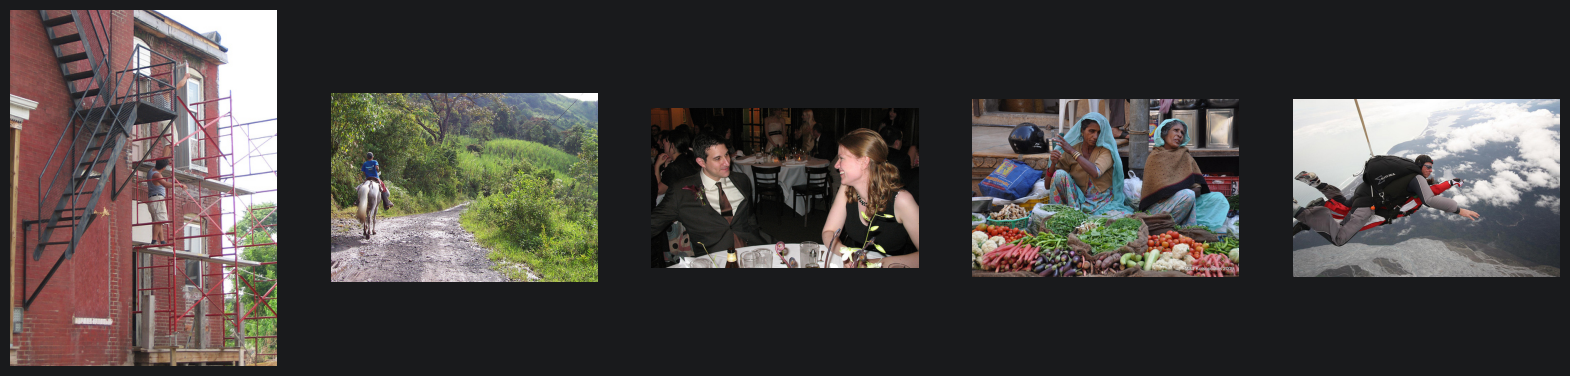

In [2]:
# Show thử 1 vài hình ảnh trong bộ dữ liệu
image_folder = "data/flickr30k_images"

# Lấy danh sách file trong thư mục hình ảnh
image_files = glob(os.path.join(image_folder, "*.jpg"))
print(f"Tổng số ảnh: {len(image_files)}")

# Chọn ngẫu nhiên 5 file hình ảnh
selected_files = random.sample(image_files, 5)

plt.figure(figsize=(20, 5))
for i, file in enumerate(selected_files):
    image = Image.open(file)
    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.axis("off")
plt.show()

In [3]:
# Tạo embedding cho 30K ảnh bằng model
model = SentenceTransformer('clip-ViT-B-32')
image_path = "data/flickr30k_images"

image_files = glob(os.path.join(image_path, "*.jpg"))
chunk_size = 256
embeddings = []


def process_chunk(chunk):
    images = [Image.open(image_file) for image_file in chunk]
    chunk_embeddings = model.encode(images)
    return chunk_embeddings


for i in range(0, len(image_files), chunk_size):
    print(f"Processing chunk {i}/{len(image_files)}...")
    chunk = image_files[i:i + chunk_size]
    embeddings.extend(process_chunk(chunk))

print(f"Đã tạo xong {len(embeddings)} embeddings.")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 8625.71it/s]


Processing chunk 0/31783...
Processing chunk 256/31783...
Processing chunk 512/31783...
Processing chunk 768/31783...
Processing chunk 1024/31783...
Processing chunk 1280/31783...
Processing chunk 1536/31783...
Processing chunk 1792/31783...
Processing chunk 2048/31783...
Processing chunk 2304/31783...
Processing chunk 2560/31783...
Processing chunk 2816/31783...
Processing chunk 3072/31783...
Processing chunk 3328/31783...
Processing chunk 3584/31783...
Processing chunk 3840/31783...
Processing chunk 4096/31783...
Processing chunk 4352/31783...
Processing chunk 4608/31783...
Processing chunk 4864/31783...
Processing chunk 5120/31783...
Processing chunk 5376/31783...
Processing chunk 5632/31783...
Processing chunk 5888/31783...
Processing chunk 6144/31783...
Processing chunk 6400/31783...
Processing chunk 6656/31783...
Processing chunk 6912/31783...
Processing chunk 7168/31783...
Processing chunk 7424/31783...
Processing chunk 7680/31783...
Processing chunk 7936/31783...
Processing chu

In [4]:
# Dựng lên vectorDB với FAISS
dimension = len(embeddings[0])
index = faiss.IndexFlatIP(dimension)
index = faiss.IndexIDMap(index)

vectors = np.array(embeddings).astype('float32')
index.add_with_ids(vectors, np.array(range(len(embeddings))))

# Save index vào file
faiss.write_index(index, "index.faiss")

# Ghi các tên ảnh vào tệp tin để load khi cần
with open("image_files.txt", "w") as f:
    for image_file in image_files:
        f.write(image_file + "\n")

print("Đã lưu FAISS index và danh sách ảnh.")

Đã lưu FAISS index và danh sách ảnh.


In [5]:
def search_image(query, model, index, image_files, top_k=5):
    """Query có thể là đường dẫn ảnh (.jpg) hoặc chuỗi text."""
    if isinstance(query, str) and query.endswith(".jpg"):
        query = Image.open(query)

    query_embedding = model.encode(query)
    query_embedding = query_embedding.astype("float32").reshape(1, -1)

    distances, indices = index.search(query_embedding, top_k)

    retrieved_image_files = [image_files[i] for i in indices[0]]
    return query, retrieved_image_files

In [6]:
def visualize_results(query, retrieved_images):
    plt.figure(figsize=(12, 5))

    # Nếu query là ảnh
    if isinstance(query, Image.Image):
        plt.subplot(1, len(retrieved_images) + 1, 1)
        plt.imshow(query)
        plt.title("Query Image")
        plt.axis('off')
        start_idx = 2
    # Nếu query là text
    else:
        plt.subplot(1, len(retrieved_images) + 1, 1)
        plt.text(0.5, 0.5, f"Query:\n\n '{query}'", fontsize=16, ha='center', va='center')
        plt.axis('off')
        start_idx = 2

    # Hiển thị ảnh kết quả
    for i, img_path in enumerate(retrieved_images):
        plt.subplot(1, len(retrieved_images) + 1, i + start_idx)
        plt.imshow(Image.open(img_path))
        plt.title(f"Match {i + 1}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

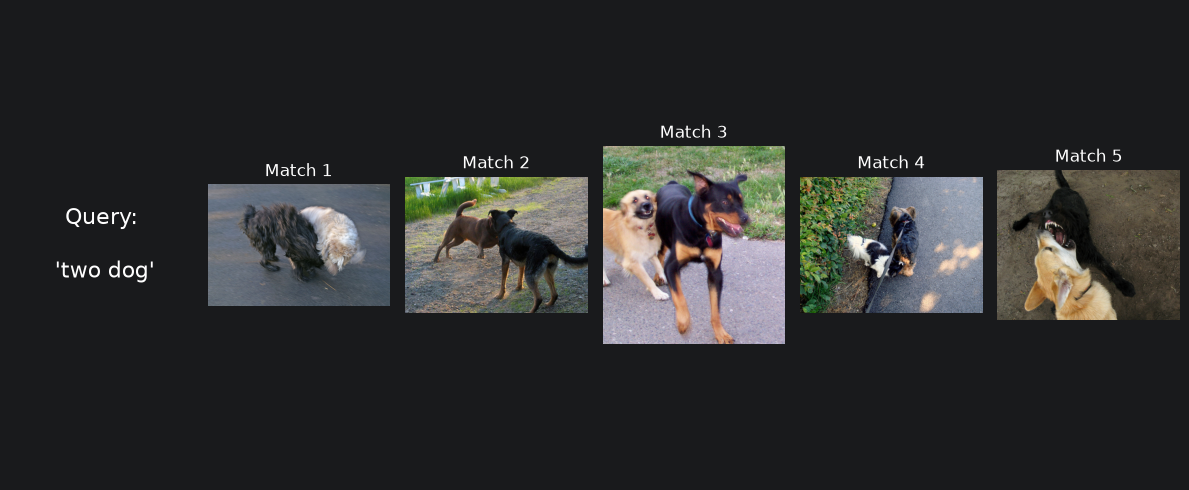

In [14]:
# Tìm kiếm từ text
query = "two dog"
query, retrieved_image_files = search_image(query, model, index, image_files)
visualize_results(query, retrieved_image_files)

In [ ]:
# Tìm kiếm từ ảnh
query_image_path = image_files[0]  # Thay bằng đường dẫn ảnh bất kỳ
query, retrieved_image_files = search_image(query_image_path, model, index, image_files)
visualize_results(query, retrieved_image_files)